1. Data Cleaning

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sklearn as sk
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import seaborn as sns
import re

df = pd.read_csv("/Users/bianca/_BIANCA_/climbing-prediction/data/raw/climbharder_df.csv")

In [ ]:
# print(df.count())
print("Columns with missing values:")
print("----------------------------")
for col in df:
    if df[col].hasnans:
        print(f"{col} | {df[col].count()} | {669 - df[col].count()} missing values | {df[col].count() / df[col].isna().sum() * 100}%")

df.iloc[1]

Columns with missing values:
----------------------------
Arm Span (cm) | 666 | 3 missing values | 22200.0%
Max Weight hangboard 18mm edge - Half crimp (KG)  (10 seconds) (added weight only) | 273 | 396 missing values | 68.93939393939394%
Max Weight hangboard 18mm edge - open crimp (KG) (10 seconds)  (added weight only) | 230 | 439 missing values | 52.391799544419136%
Min Edge used (mm, +kg if weight added ) - Half Crimp (10 seconds) | 222 | 447 missing values | 49.664429530201346%
Min Edge used (mm, +kg if weight added) - Open crimp (10 seconds)  | 187 | 482 missing values | 38.796680497925315%
Endurance training  | 645 | 24 missing values | 2687.5%
Other activities (ie yoga, cardio) | 328 | 341 missing values | 96.18768328445748%
Max pull up reps | 538 | 131 missing values | 410.6870229007634%
5 rep max weighted pull ups | 361 | 308 missing values | 117.20779220779221%
max push ups reps | 440 | 229 missing values | 192.13973799126637%
max L-sit time  | 289 | 380 missing values | 76.0

Timestamp                                                                                                           29/01/2017 20:17:27
Sex                                                                                                                                Male
Height (cm)                                                                                                                         180
Weight (KG)                                                                                                                          81
Arm Span (cm)                                                                                                                       180
How long have you been climbing for?                                                                                      3 - 3.5 years
Where do you climb?                                                                                                Indoor Climbing only
Hardest V Grade ever climbed                    

In [ ]:
pd.set_option('future.no_silent_downcasting', True)

# Remove all columns with NaN (simplification purposes)
cols_drop = [col for col in df if df[col].isnull().values.any()]

# df2 = df2.drop(cols_drop, axis=1)
print(df["Sex"].unique())
df["Sex"] = df["Sex"].replace({
    "Male":0,
    "Female":1
})

# Figure out how to convert cm to ft
df["Height (cm)"] = df["Height (cm)"].replace({
    
})

print(df)

print(df["Sex"].value_counts())

'''df2 = df2.select_dtypes(include='number')

print(list(df2.columns.values))

plt.figure(figsize=(15,10))

# Find correlation between numerical values - would not make much sense 
corrs = df2.corr()
sns.heatmap(round(corrs,2), cmap='RdBu', annot=True, 
            annot_kws={"size": 7}, vmin=-1, vmax=1)'''

# cols_str = [col for col in df2 if df2[col].dtype]

['Male' 'Female']
               Timestamp Sex Height (cm) Weight (KG) Arm Span (cm)  \
0    29/01/2017 20:12:46   0         173          77           178   
1    29/01/2017 20:17:27   0         180          81           180   
2    29/01/2017 20:28:14   0         178          67           175   
3    29/01/2017 20:51:08   0         173          70           178   
4    29/01/2017 21:03:19   0         184          84           197   
..                   ...  ..         ...         ...           ...   
664  24/01/2026 12:35:01   0      175.25        56.7           176   
665  17/03/2026 07:24:12   0         183          82           183   
666  19/03/2026 20:53:55   0      167.64      58.967        170.18   
667  07/04/2026 11:50:10   0       172.2        72.7           181   
668  12/06/2026 06:32:00   0         183          79           183   

    How long have you been climbing for?          Where do you climb?  \
0                          4.5 - 5 years  Indoor and outdoor climbin

'df2 = df2.select_dtypes(include=\'number\')\n\nprint(list(df2.columns.values))\n\nplt.figure(figsize=(15,10))\n\n# Find correlation between numerical values - would not make much sense \ncorrs = df2.corr()\nsns.heatmap(round(corrs,2), cmap=\'RdBu\', annot=True, \n            annot_kws={"size": 7}, vmin=-1, vmax=1)'

In [ ]:
df2

,Timestamp,Sex,Height (cm),Weight (KG),Arm Span (cm),How long have you been climbing for?,Where do you climb?,Hardest V Grade ever climbed,Hardest V Grade climbed in the Last 3 months,The V grade you can send 90-100% of routes,...,Frequency of Endurance training sesions per week,Endurance training,General Strength Training frequency per week,Time spent General strength training (hours),Type of Strength training,"Other activities (ie yoga, cardio)",Max pull up reps,5 rep max weighted pull ups,max push ups reps,max L-sit time
0,29/01/2017 20:12:46,0,173,77,178,4.5 - 5 years,Indoor and outdoor climbing,V8,V8,V6,...,1,4x4,3,4,"Antagonists, Legs, Core",NaN,15,29kg,40,30
1,29/01/2017 20:17:27,0,180,81,180,3 - 3.5 years,Indoor Climbing only,V3,V3,V1,...,1,Laps of routes,2,2,"Antagonists, Legs, Core, Upper body pulling, U...","Yoga, stretching",11,5kg,24,15sec
2,29/01/2017 20:28:14,0,178,67,175,.5 - 1 years,Indoor and outdoor climbing,V7,V6,V5,...,2,"4x4, ARC, route climbing intervals",3,2,"Antagonists, Core, Upper body pulling, Upper b...",soccer,17,20 kg,NaN,NaN
3,29/01/2017 20:51:08,0,173,70,178,9 - 9.5 years,Indoor and outdoor climbing,V5,V4,V3,...,1,"Laps of routes, route climbing intervals",0,0,"Antagonists, Legs, Core, No other strength tra...",NaN,8,NaN,30,NaN
4,29/01/2017 21:03:19,0,184,84,197,6.5 - 7 years,Indoor and outdoor climbing,V10,V10,V7,...,2,"4x4, Max moves, threshold intervals",2,1,"Core, Upper body pushing",NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,24/01/2026 12:35:01,0,175.25,56.7,176,7 - 7.5 years,Indoor and outdoor climbing,V9,V9,V7,...,0,I don't train for endurance,2,2,"Antagonists, Legs, Core, Upper body pulling, U...",Surfing,+30,22.7,+20,NaN
665,17/03/2026 07:24:12,0,183,82,183,0 - .5 years,Indoor Climbing only,V6,V6,V4,...,0,I don't train for endurance,3,2,"Upper body pulling, Upper body pushing",NaN,22,30,50,NaN
666,19/03/2026 20:53:55,0,167.64,58.967,170.18,3.5 - 4 years,Indoor and outdoor climbing,V8,V7,V6,...,1,"4x4, hangboard repeater protocols",0,0,No other strength training,yoga,10,NaN,20,NaN
667,07/04/2026 11:50:10,0,172.2,72.7,181,More than 15 years,Indoor and outdoor climbing,V8,V8,V7,...,1,"4x4, Laps of routes, route climbing intervals",1,1,"Legs, Core, Upper body pulling, Upper body pus...",Occasional yoga/stretching.,17,20kg,25,33


In [ ]:
df2["Height (cm)"].unique()
df2["Weight (KG)"].unique()

df["Height (cm)"].value_counts(dropna=False)
'''
height:
3 have strings
units - cm, m, ft
'''

'''
standardize:
    lowercase
    remove all text
if contains ft
    convert ft -> cm, remove ft
if contains m
    convert m -> cm, remove m
if contains cm
    remove cm
if > max or < min
    replace with NA
if < meter max
    conver to cm
else 
    stay the same
'''

# df["Weight (KG)"].value_counts(dropna=False)

0      False
1      False
2      False
3      False
4      False
       ...  
664    False
665    False
666    False
667    False
668    False
Name: Sex, Length: 669, dtype: bool

# CSK WORK

In [ ]:
df["Arm Span (cm)"].unique()
len(df)

669

Female responses: 13.303437967115098%
Male responses: 86.6965620328849%


Text(0.5, 1.0, 'Survey responses by gender')

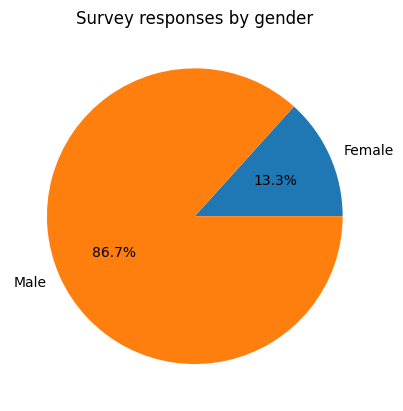

In [ ]:
import math

df['Sex'].value_counts()

print(f"Female responses: {89/669*100}%")
print(f"Male responses: {580/669*100}%")

fig, ax = plt.subplots()
sizes = [89/669*100, 580/669*100]
ax.pie(sizes, labels=['Female', 'Male'], autopct='%1.1f%%')
plt.title('Survey responses by gender')

In [ ]:
df = pd.read_csv('/Users/bianca/_BIANCA_/climbing-prediction/data/processed/climbharder_df_cleaned.csv')
df["Arm Span (cm)"].unique()

array([178. , 180. , 175. , 197. , 170. , 181. , 192. ,   nan, 158. ,
       165. , 195.6, 177. , 186. , 165.1, 155. , 185. , 190. , 179. ,
       173. , 182. , 168. , 187. , 184. , 193. , 176. , 189. , 172. ,
       183. , 195. , 185.5, 163. , 171. , 200. , 196. , 177.5, 167. ,
       194. , 188. , 190.5, 157. , 174. , 166. , 169. , 161. , 177.9,
       150. , 199. , 159. , 191. , 180.3, 198. , 167.5, 177.8, 170.7,
       160. , 152. , 201. , 203. , 162. , 193.4, 164. , 198.1, 130. ,
       204. , 160.6, 148. , 208. , 159.6, 162.6, 185.9, 167.6, 144. ,
       152.4, 191.7, 154. , 178.8, 169.2, 153. , 170.2])

In [ ]:
print("Columns with missing values:")
print("----------------------------")
for col in df:
    if df[col].hasnans:
        print(f"{col} | {df[col].count()} values | {669 - df[col].count()} missing values | {(df[col].count() / df[col].isna().sum()) * 100}%")

df.iloc[1]
df.dtypes

Columns with missing values:
----------------------------
Height (cm) | 665 values | 4 missing values | 16625.0%
Weight (KG) | 659 values | 10 missing values | 6590.000000000001%
Arm Span (cm) | 631 values | 38 missing values | 1660.5263157894735%
Max Weight hangboard 18mm edge - Half crimp (KG)  (10 seconds) (added weight only) | 252 values | 417 missing values | 60.431654676258994%
Max Weight hangboard 18mm edge - open crimp (KG) (10 seconds)  (added weight only) | 205 values | 464 missing values | 44.18103448275862%
Min Edge used (mm, +kg if weight added ) - Half Crimp (10 seconds) | 222 values | 447 missing values | 49.664429530201346%
Min Edge used (mm, +kg if weight added) - Open crimp (10 seconds)  | 187 values | 482 missing values | 38.796680497925315%
Endurance training  | 645 values | 24 missing values | 2687.5%
Other activities (ie yoga, cardio) | 328 values | 341 missing values | 96.18768328445748%
Max pull up reps | 526 values | 143 missing values | 367.83216783216784%
5 r

Timestamp                                                                              object
Sex                                                                                    object
Height (cm)                                                                           float64
Weight (KG)                                                                           float64
Arm Span (cm)                                                                         float64
How long have you been climbing for?                                                   object
Where do you climb?                                                                    object
Hardest V Grade ever climbed                                                           object
Hardest V Grade climbed in the Last 3 months                                           object
The V grade you can send 90-100% of routes                                             object
Hardest Route grade climbed (Ewbank grade)                  

In [ ]:
df['How long have you been climbing for?'].unique()
# df = df.rename(columns={"The V grade you can send 90-100% of routes (numeric)": "The V grade you can send 90-100% of routes (numeric)"})
df.columns



Index(['Timestamp', 'Sex', 'Height (cm)', 'Weight (KG)', 'Arm Span (cm)',
       'How long have you been climbing for?', 'Where do you climb?',
       'Hardest V Grade ever climbed ',
       'Hardest V Grade climbed in the Last 3 months',
       'The V grade you can send 90-100% of routes ',
       'Hardest Route grade climbed (Ewbank grade) ',
       'Hardest route climbed last 3 months (ewbank)',
       'Route grade you can send 90-100% of climbs',
       'Frequency of climbing sessions per week',
       'Average hours climbing per week (not including training)',
       'Average hours Training for climbing per week ',
       'Hangboard Frequency per week ', 'Hangboard grips used ',
       'Style of Hangboarding chosen ',
       'Max Weight hangboard 18mm edge - Half crimp (KG)  (10 seconds) (added weight only)',
       'Max Weight hangboard 18mm edge - open crimp (KG) (10 seconds)  (added weight only)',
       'Min Edge used (mm, +kg if weight added ) - Half Crimp (10 seconds)',
    

In [ ]:
df.columns

dfc = df[['Sex', 'Height (cm)', 'Weight (KG)', 'Where do you climb?', 'Frequency of climbing sessions per week', 'Arm Span (cm)', 'Frequency of Endurance training sesions per week', 'How long have you been climbing for? (years, numeric)', 'Average hours climbing per week (not including training)', 'Average hours Training for climbing per week ', 'Hangboard Frequency per week ', 'Hardest V Grade ever climbed (numeric)', 'The V grade you can send 90-100% of routes (numeric)', 'Half Crimp (10 seconds) - Min Edge (mm, cleaned)', 'Open crimp (10 seconds) - Min Edge (mm, cleaned)', 'Max pull up reps', 'max push ups reps', 'max L-sit time ','General Strength Training frequency per week ', 'Campus Board frequency per week ', 'Campus Board time per week (hours)' ]].copy()
dfc
# new cleaned df


,Sex,Height (cm),Weight (KG),Where do you climb?,Frequency of climbing sessions per week,Arm Span (cm),Frequency of Endurance training sesions per week,"How long have you been climbing for? (years, numeric)",Average hours climbing per week (not including training),Average hours Training for climbing per week,...,Hardest V Grade ever climbed (numeric),The V grade you can send 90-100% of routes (numeric),"Half Crimp (10 seconds) - Min Edge (mm, cleaned)","Open crimp (10 seconds) - Min Edge (mm, cleaned)",Max pull up reps,max push ups reps,max L-sit time,General Strength Training frequency per week,Campus Board frequency per week,Campus Board time per week (hours)
0,Male,173.0,77.00,Indoor and outdoor climbing,4,178.0,1,4.75,8,6,...,8.0,6.0,NaN,NaN,15.0,40.0,30.0,3,0,0
1,Male,180.0,81.00,Indoor Climbing only,1,180.0,1,3.25,3,10,...,3.0,1.0,NaN,NaN,11.0,24.0,15.0,2,0,0
2,Male,178.0,67.00,Indoor and outdoor climbing,3,175.0,2,0.75,4,3,...,7.0,5.0,NaN,NaN,17.0,NaN,NaN,3,0,0
3,Male,173.0,70.00,Indoor and outdoor climbing,2,178.0,1,9.25,6,1,...,5.0,3.0,NaN,NaN,8.0,30.0,NaN,0,0,0
4,Male,184.0,84.00,Indoor and outdoor climbing,6,197.0,2,6.75,10,2,...,10.0,7.0,8.0,8.0,NaN,NaN,NaN,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,Male,175.2,56.70,Indoor and outdoor climbing,2,176.0,0,7.25,3,2,...,9.0,7.0,8.0,15.0,30.0,20.0,NaN,2,0,0
665,Male,183.0,82.00,Indoor Climbing only,1,183.0,0,0.25,2,1,...,6.0,4.0,10.0,NaN,22.0,50.0,NaN,3,0,0
666,Male,167.6,58.97,Indoor and outdoor climbing,3,170.2,1,3.75,6,1,...,8.0,6.0,15.0,20.0,10.0,20.0,NaN,0,0,0
667,Male,172.2,72.70,Indoor and outdoor climbing,2,181.0,1,15.75,5,2,...,8.0,7.0,5.0,5.0,17.0,25.0,33.0,1,2,1


In [ ]:
dfc.columns
# columns in dfc

Index(['Sex', 'Height (cm)', 'Weight (KG)', 'Where do you climb?',
       'Frequency of climbing sessions per week', 'Arm Span (cm)',
       'Frequency of Endurance training sesions per week',
       'How long have you been climbing for? (years, numeric)',
       'Average hours climbing per week (not including training)',
       'Average hours Training for climbing per week ',
       'Hangboard Frequency per week ',
       'Hardest V Grade ever climbed (numeric)',
       'The V grade you can send 90-100% of routes (numeric)',
       'Half Crimp (10 seconds) - Min Edge (mm, cleaned)',
       'Open crimp (10 seconds) - Min Edge (mm, cleaned)', 'Max pull up reps',
       'max push ups reps', 'max L-sit time ',
       'General Strength Training frequency per week ',
       'Campus Board frequency per week ',
       'Campus Board time per week (hours)'],
      dtype='object')

AttributeError: Rectangle.set() got an unexpected keyword argument 'index'

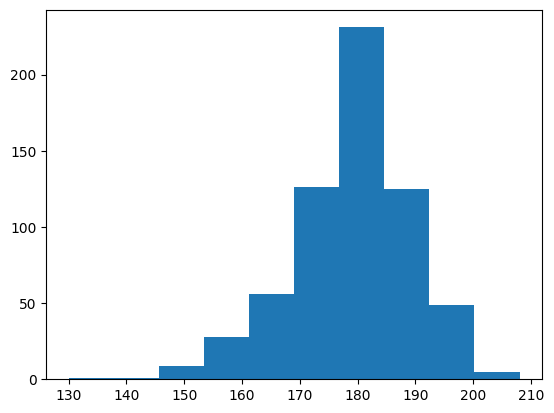

In [ ]:

fig, ax = plt.subplots()
plt.hist(df['Arm Span (cm)'], index='num grade')

fig, ax = plt.subplots()
plt.scatter(df['Arm Span (cm)'], df['num grade'])

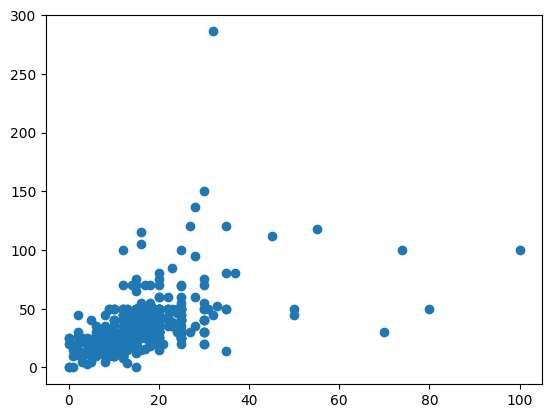

In [ ]:
fig, ax = plt.subplots()
plt.scatter(df['Max pull up reps'], df['max push ups reps'])

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
[0.55, 2.514705882352941, 1.6571428571428573, 2.547169811320755, 3.693708609271523, 4.567391304347826, 6.326923076923077, 7.386363636363637, 7.159090909090909, 9.041666666666666, 10.083333333333334, 13.25]


Text(0.5, 0, 'V Grade')

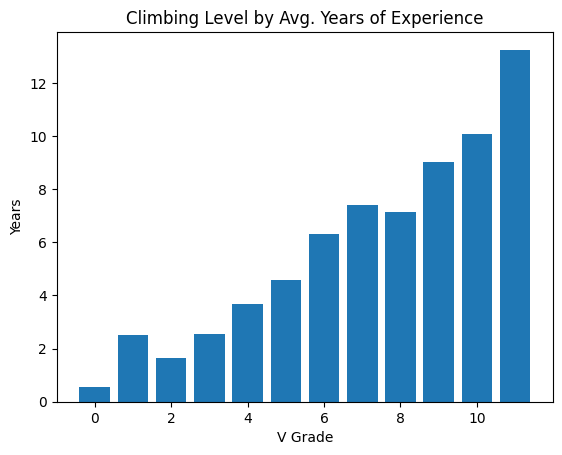

In [ ]:

# comment out num grade
'''mean_pushups = dfc.groupby("num grade")['max push ups reps'].mean()
mean_pushups

mean_grade = dfc.groupby('Sex')['num grade'].mean()
mean_grade

grades = pd.DataFrame(mean_grade)
grades = grades.rename(columns={'num grade': 'Avg V grade'})
grades'''

# YEARS CLIMBED BY V GRADE

yrs_climbed = dfc.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean().tolist()
yrs_climbed

labels = dfc['The V grade you can send 90-100% of routes (numeric)'].dropna().unique().tolist()
labels.sort()

print(labels)
print(yrs_climbed)

plt.bar(labels, yrs_climbed)
plt.title('Climbing Level by Avg. Years of Experience')
plt.ylabel('Years')
plt.xlabel('V Grade')


# plt.scatter(0, mean_pushups)



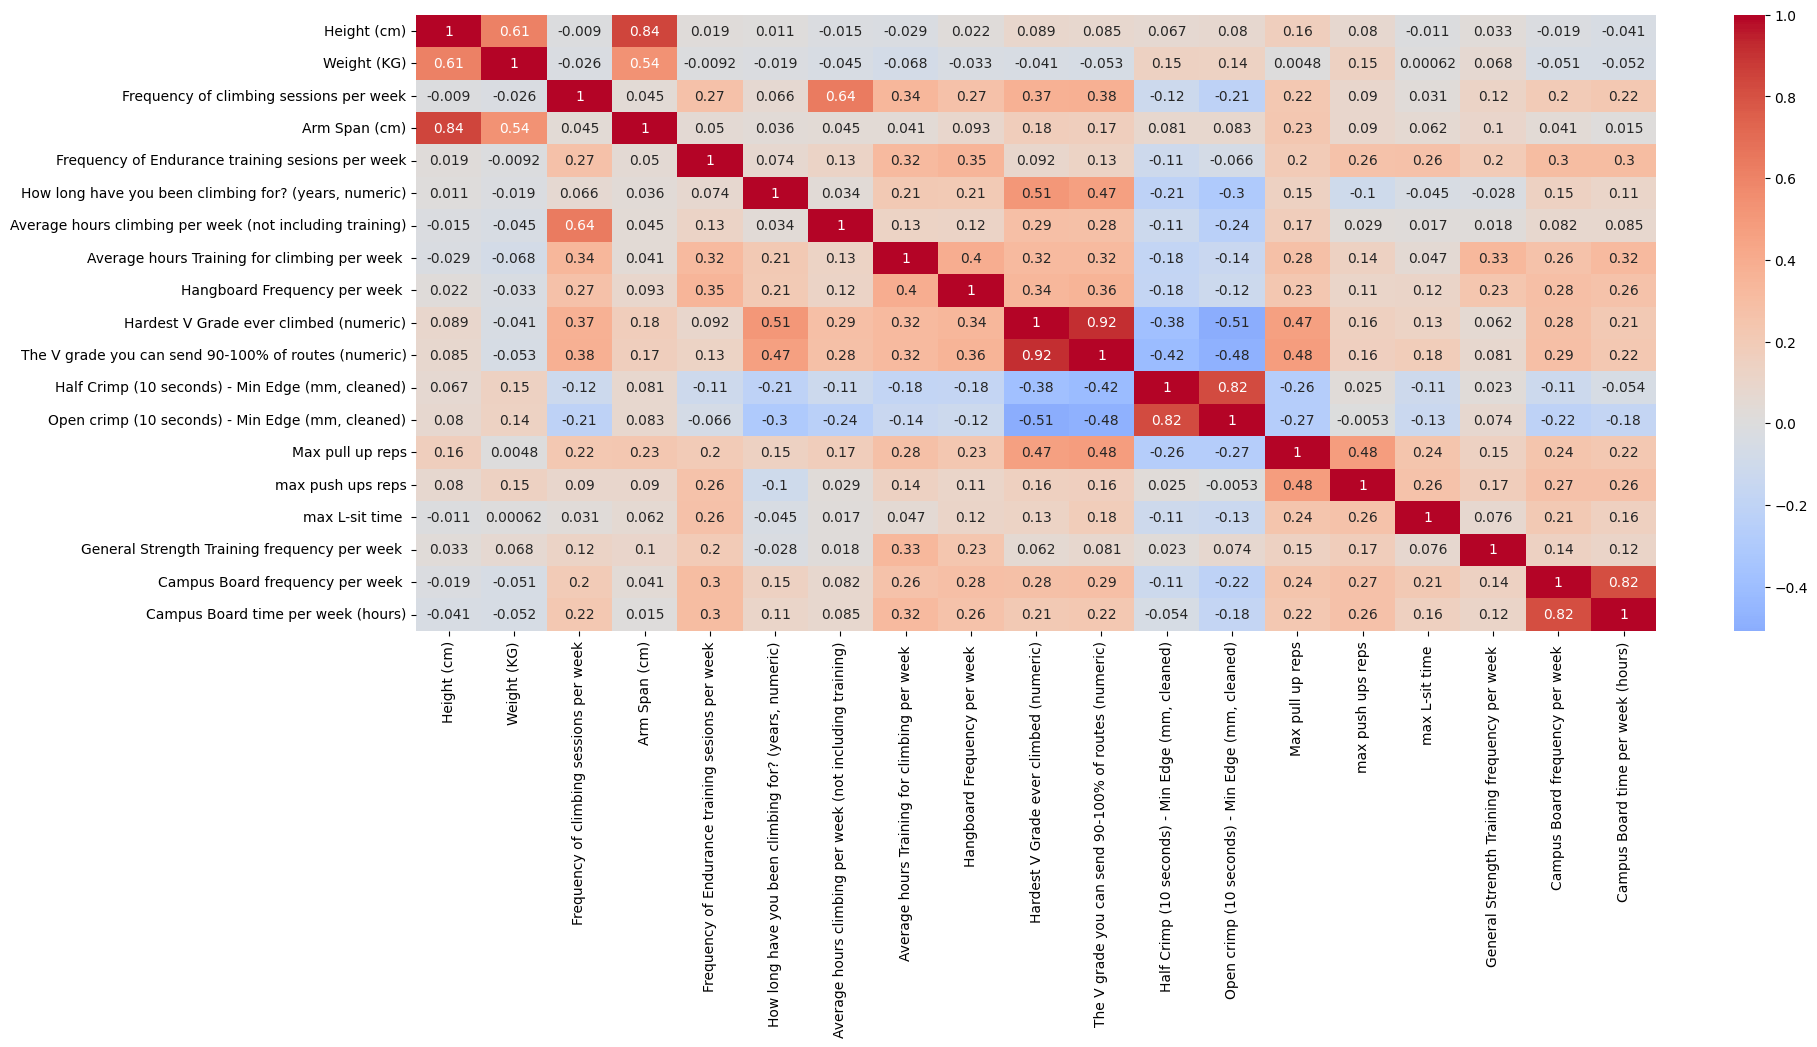

The V grade you can send 90-100% of routes (numeric)        1.000000
Hardest V Grade ever climbed (numeric)                      0.916627
Max pull up reps                                            0.477365
How long have you been climbing for? (years, numeric)       0.465291
Frequency of climbing sessions per week                     0.379739
Hangboard Frequency per week                                0.357838
Average hours Training for climbing per week                0.315771
Campus Board frequency per week                             0.285764
Average hours climbing per week (not including training)    0.281137
Campus Board time per week (hours)                          0.224242
max L-sit time                                              0.183749
Arm Span (cm)                                               0.167654
max push ups reps                                           0.163382
Frequency of Endurance training sesions per week            0.131371
Height (cm)                       

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = dfc.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

corr["The V grade you can send 90-100% of routes (numeric)"].sort_values(ascending=False)

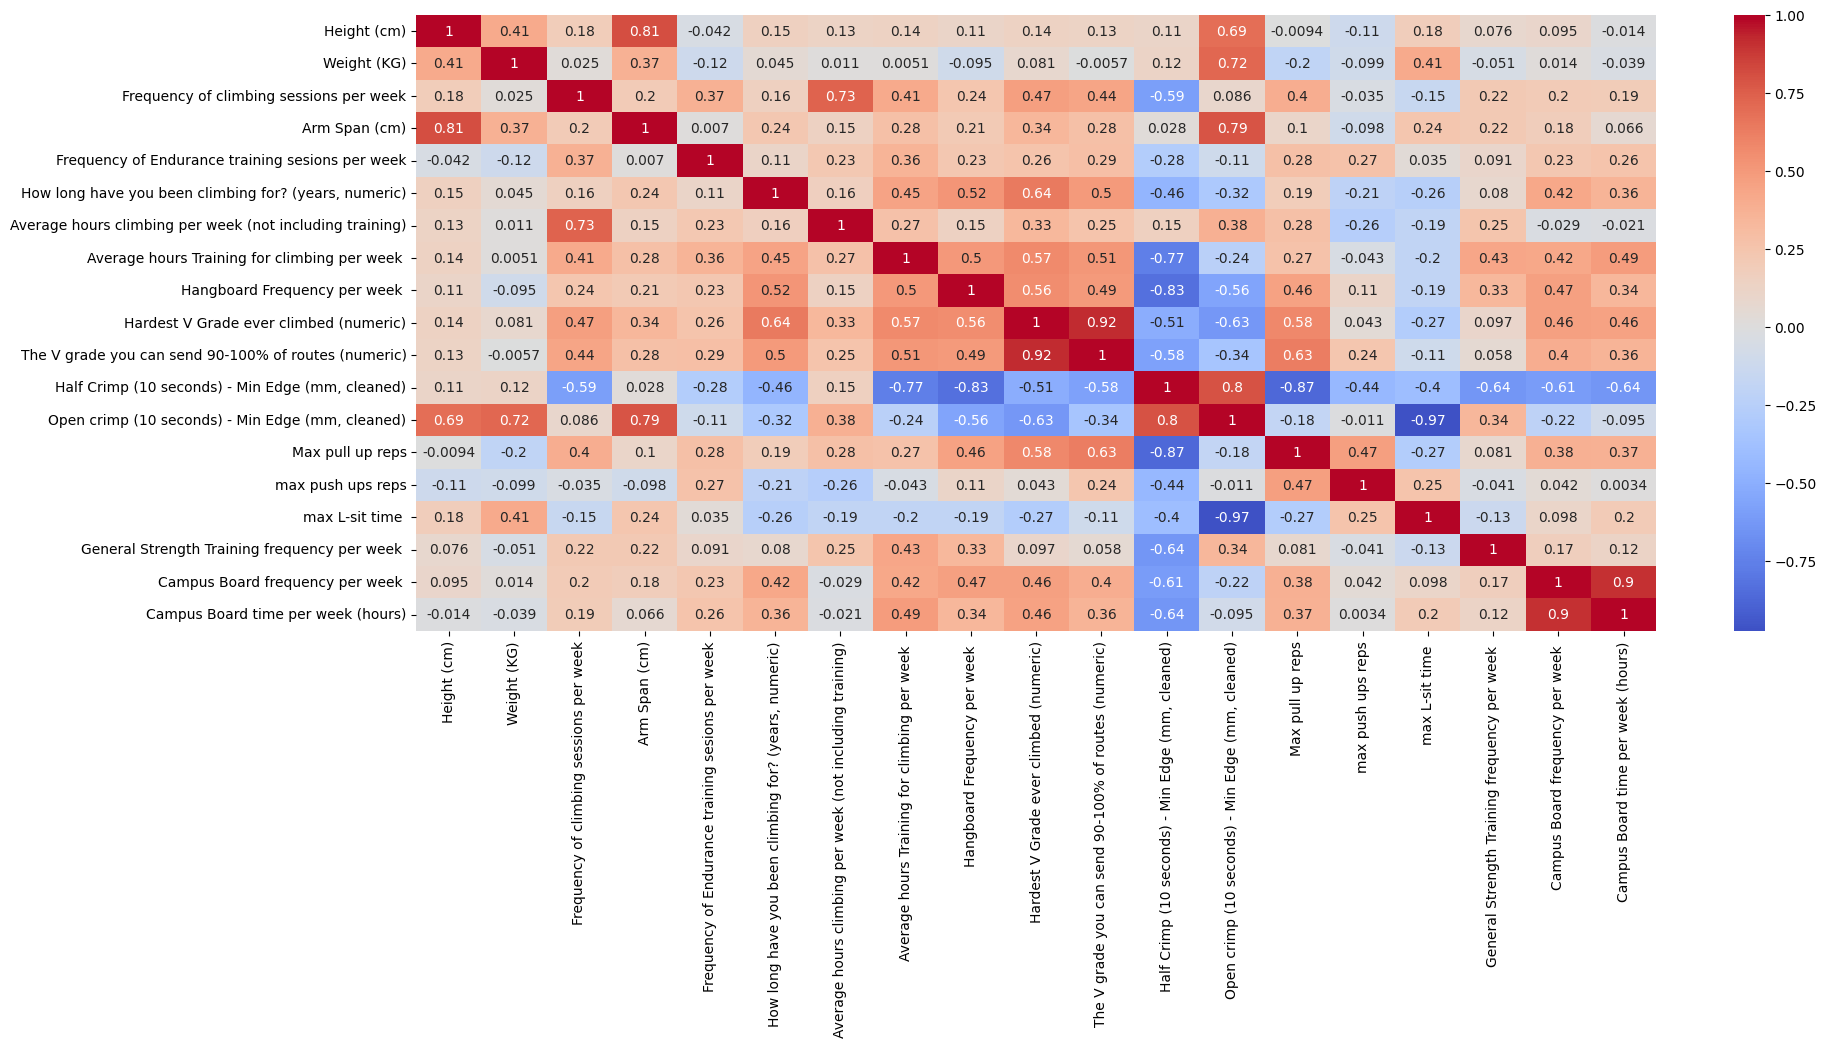

The V grade you can send 90-100% of routes (numeric)        1.000000
Hardest V Grade ever climbed (numeric)                      0.917310
Max pull up reps                                            0.626484
Average hours Training for climbing per week                0.508377
How long have you been climbing for? (years, numeric)       0.498582
Hangboard Frequency per week                                0.493706
Frequency of climbing sessions per week                     0.444613
Campus Board frequency per week                             0.395398
Campus Board time per week (hours)                          0.358890
Frequency of Endurance training sesions per week            0.289099
Arm Span (cm)                                               0.281738
Average hours climbing per week (not including training)    0.252234
max push ups reps                                           0.243857
Height (cm)                                                 0.132849
General Strength Training frequenc

"yrs_climbed = dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean().tolist()\nyrs_climbed\n\nyrs_climbed = dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean()"

In [ ]:
# dfc = dfc.drop('num grade', axis=1)

# Correlations by women
dfc_women = dfc[dfc['Sex']=='Female']
len(dfc_women)
dfc_women

####

corr = dfc_women.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

print(corr["The V grade you can send 90-100% of routes (numeric)"].sort_values(ascending=False))

'''yrs_climbed = dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean().tolist()
yrs_climbed

yrs_climbed = dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean()'''



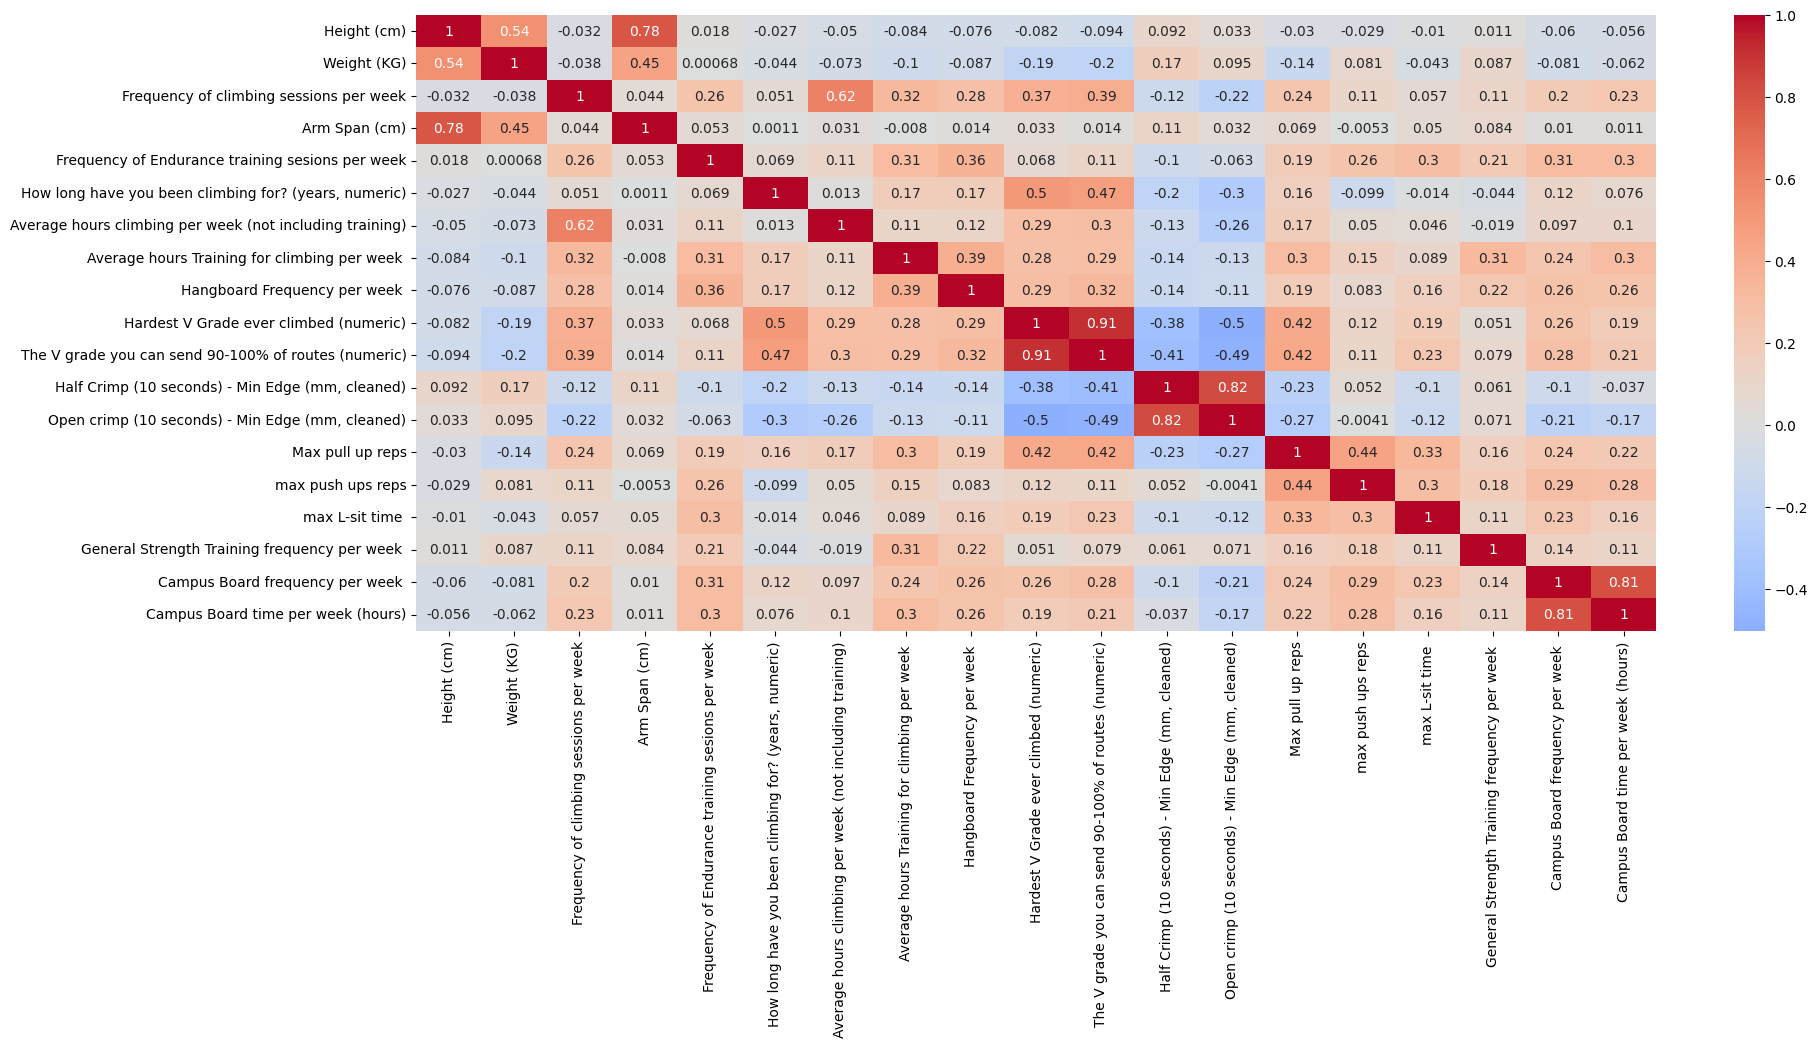

The V grade you can send 90-100% of routes (numeric)        1.000000
Hardest V Grade ever climbed (numeric)                      0.910404
How long have you been climbing for? (years, numeric)       0.471572
Max pull up reps                                            0.424475
Frequency of climbing sessions per week                     0.390654
Hangboard Frequency per week                                0.323114
Average hours climbing per week (not including training)    0.295445
Average hours Training for climbing per week                0.289315
Campus Board frequency per week                             0.275525
max L-sit time                                              0.228819
Campus Board time per week (hours)                          0.214040
Frequency of Endurance training sesions per week            0.111020
max push ups reps                                           0.105762
General Strength Training frequency per week                0.079281
Arm Span (cm)                     

[0.25,
 3.361111111111111,
 1.25,
 2.3555555555555556,
 3.5384615384615383,
 4.5157657657657655,
 6.181506849315069,
 7.083333333333333,
 7.266129032258065,
 9.041666666666666,
 10.083333333333334,
 13.25]

In [ ]:
# Correlations by men

dfc_men = dfc[dfc['Sex']=='Male']
len(dfc_men)
dfc_men

dfc_men

####

corr = dfc_men.corr(numeric_only=True)

plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

print(corr["The V grade you can send 90-100% of routes (numeric)"].sort_values(ascending=False))

yrs_climbed = dfc_men.groupby('The V grade you can send 90-100% of routes (numeric)')['How long have you been climbing for? (years, numeric)'].mean().tolist()
yrs_climbed

In [ ]:
plt.figure(figsize=(20,8))
plt.scatter(dfc['The V grade you can send 90-100% of routes (numeric)'], )
plt.show()

In [ ]:
# dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['Max pull up reps'].mean()

dfc_women.groupby('The V grade you can send 90-100% of routes (numeric)')['Max pull up reps']

The V grade you can send 90-100% of routes (numeric)
0.0     0.000000
1.0     3.666667
2.0     3.421053
3.0     7.066667
4.0    10.333333
5.0    12.750000
6.0    14.600000
7.0    10.000000
8.0    12.000000
Name: Max pull up reps, dtype: float64

In [ ]:
dfc_men.groupby('The V grade you can send 90-100% of routes (numeric)')['Max pull up reps'].mean()

The V grade you can send 90-100% of routes (numeric)
0.0      5.000000
1.0     11.714286
2.0     13.414634
3.0     12.973333
4.0     15.470588
5.0     18.390244
6.0     19.315789
7.0     25.038462
8.0     24.886364
9.0     21.888889
10.0    32.833333
11.0    25.000000
Name: Max pull up reps, dtype: float64